In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from category_encoders import BinaryEncoder, OneHotEncoder
import gc

In [2]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [3]:
df = pd.read_csv(r"C:\Users\ashrq\ML-Projects\nti-graduation-project\Fraud-detection\PS_20174392719_1491204439457_log.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.640,C1231006815,170136.000,160296.360,M1979787155,0.000,0.000,0,0
1,1,PAYMENT,1864.280,C1666544295,21249.000,19384.720,M2044282225,0.000,0.000,0,0
2,1,TRANSFER,181.000,C1305486145,181.000,0.000,C553264065,0.000,0.000,1,0
3,1,CASH_OUT,181.000,C840083671,181.000,0.000,C38997010,21182.000,0.000,1,0
4,1,PAYMENT,11668.140,C2048537720,41554.000,29885.860,M1230701703,0.000,0.000,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.130,C786484425,339682.130,0.000,C776919290,0.000,339682.130,1,0
6362616,743,TRANSFER,6311409.280,C1529008245,6311409.280,0.000,C1881841831,0.000,0.000,1,0
6362617,743,CASH_OUT,6311409.280,C1162922333,6311409.280,0.000,C1365125890,68488.840,6379898.110,1,0
6362618,743,TRANSFER,850002.520,C1685995037,850002.520,0.000,C2080388513,0.000,0.000,1,0


In [4]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [5]:
df.drop(['nameOrig', 'nameDest'], axis = 1, inplace = True)

In [6]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
pd.concat([df[df['isFraud'] == 1].sample(1000), df[df['isFraud'] == 0].sample(1000)]).to_csv("fraud_Sample.csv")

In [8]:
stop

NameError: name 'stop' is not defined

In [ ]:
normal = df[df['isFraud'] == 0].sample(2000000)
fraud = df[df['isFraud'] == 1]
df = pd.concat([normal, fraud], axis = 0)
df.shape

(2008213, 9)

In [ ]:
df.isnull().sum()

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(65)

In [ ]:
df.drop_duplicates()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3418884,256,CASH_IN,51158.150,7017302.500,7068460.650,4808312.300,4757154.150,0,0
3565620,260,CASH_OUT,5710.190,0.000,0.000,50180.520,55890.700,0,0
11552,7,PAYMENT,6099.890,0.000,0.000,0.000,0.000,0,0
213136,13,PAYMENT,492.850,39864.000,39371.150,0.000,0.000,0,0
2831144,226,DEBIT,1547.450,0.000,0.000,88347.750,89895.210,0,0
...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.130,339682.130,0.000,0.000,339682.130,1,0
6362616,743,TRANSFER,6311409.280,6311409.280,0.000,0.000,0.000,1,0
6362617,743,CASH_OUT,6311409.280,6311409.280,0.000,68488.840,6379898.110,1,0
6362618,743,TRANSFER,850002.520,850002.520,0.000,0.000,0.000,1,0


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,2008213.000,2008213.000,2008213.000,2008213.000,2008213.000,2008213.000,2008213.000,2008213.000
mean,243.760,183347.592,836972.558,854076.438,1100944.882,1226879.648,0.004,0.000
std,142.735,616789.816,2892006.391,2923508.221,3449793.326,3716852.134,0.064,0.003
min,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,156.000,13441.650,0.000,0.000,0.000,0.000,0.000,0.000
50%,239.000,75236.910,14516.000,0.000,131650.800,214282.140,0.000,0.000
75%,335.000,209516.830,108478.380,143378.230,941003.070,1112363.720,0.000,0.000
max,743.000,73823490.360,59585040.370,49585040.370,355553416.300,355553416.300,1.000,1.000


In [ ]:
from scipy import stats
report = []
numerical = ['step',  'amount',  'oldbalanceOrg', 'newbalanceOrig',
        'oldbalanceDest', 'newbalanceDest']
for col in numerical:
    # iqr outliers
    q1, q3 = np.percentile(df[col], [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    higher  = q3 + 1.5 * iqr
    iqr_outliers =( (df[col] < lower) | (df[col] > higher)).sum()
    # z_score outliers
    z = np.abs(stats.zscore(df[col], nan_policy="omit"))
    z_outliers = (z > 3).sum()

    report.append({
        "Feature" : col,
        "min": df[col].min(),
        "max": df[col].max(),
        "mean" : df[col].mean(),
        "median" : df[col].median(),
        "std" : df[col].std(),
        "skew": df[col].skew(),
        "kurtosis": df[col].kurtosis(),
        "IQR Outliers" : iqr_outliers,
        "Z_score Outliers" : z_outliers, 
        "IQR Outliers Percentile" : (iqr_outliers / len(df[col])) * 100, 
        "Z_score Outliers Percentile" : (z_outliers / len(df[col])) * 100
     })
report = pd.DataFrame(report)
report

,Feature,min,max,mean,median,std,skew,kurtosis,IQR Outliers,Z_score Outliers,IQR Outliers Percentile,Z_score Outliers Percentile
0,step,1.000,743.000,243.760,239.000,142.735,0.383,0.335,33359,21452,1.661,1.068
1,amount,0.000,73823490.360,183347.592,75236.910,616789.816,28.874,1569.432,108517,14782,5.404,0.736
2,oldbalanceOrg,0.000,59585040.370,836972.558,14516.000,2892006.391,5.255,33.164,352396,48911,17.548,2.436
3,newbalanceOrig,0.000,49585040.370,854076.438,0.000,2923508.221,5.187,32.229,332580,49090,16.561,2.444
4,oldbalanceDest,0.000,355553416.300,1100944.882,131650.800,3449793.326,21.776,1136.398,248722,24514,12.385,1.221
5,newbalanceDest,0.000,355553416.300,1226879.648,214282.140,3716852.134,20.627,985.339,233369,23152,11.621,1.153


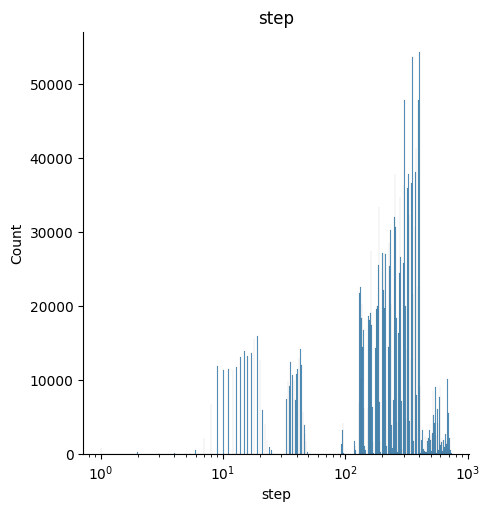

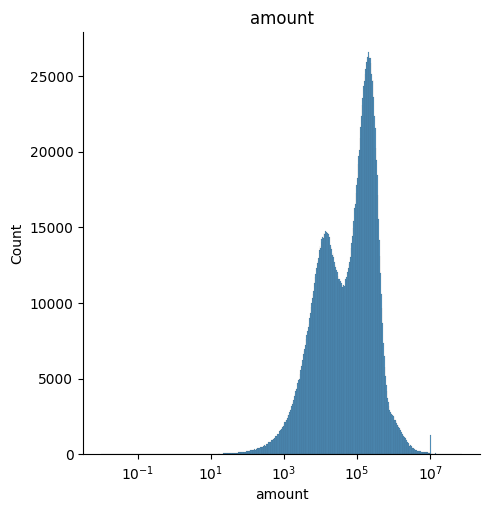

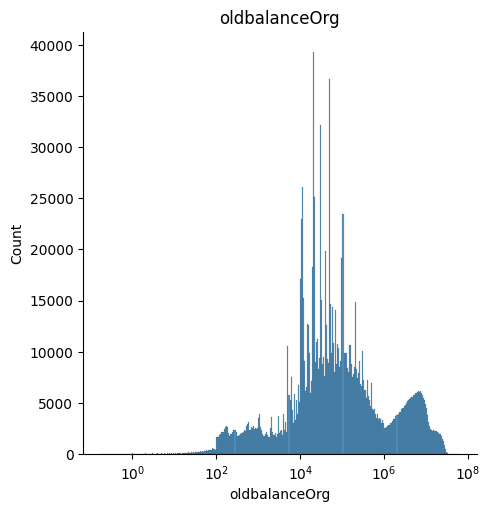

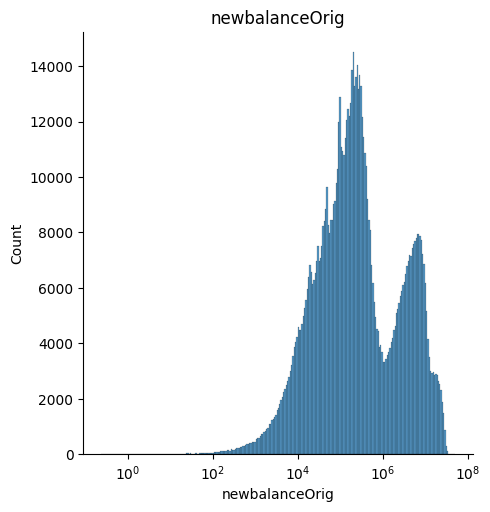

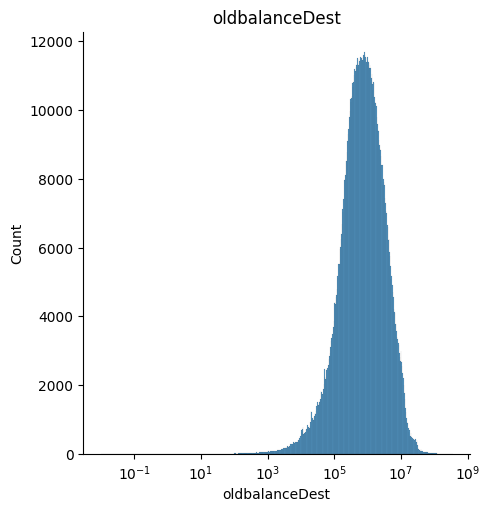

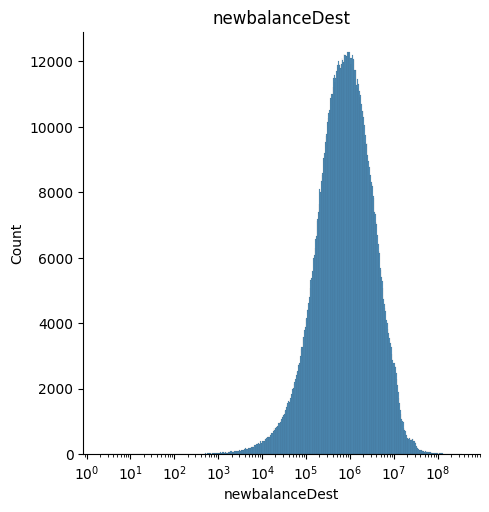

In [ ]:
for col in numerical:
    sns.displot(df[col], log_scale=True)
    plt.title(col)
    plt.show()

In [ ]:
X = df.drop(['isFraud', 'isFlaggedFraud'], axis = 1)
y = df['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state=42, shuffle=True)
X_normal = X_train[y_train == 0]

In [ ]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), 'type'),
    ("num", MinMaxScaler(), ['step',  'amount', 'oldbalanceDest', 'newbalanceDest', 'oldbalanceOrg', 'newbalanceOrig'])
])

X_train = preprocessor.fit_transform(X_train)
X_normal = preprocessor.transform(X_normal)
X_test = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

In [ ]:
feature_names

array(['cat__type_1', 'cat__type_2', 'cat__type_3', 'cat__type_4',
       'cat__type_5', 'num__step', 'num__amount', 'num__oldbalanceDest',
       'num__newbalanceDest', 'num__oldbalanceOrg', 'num__newbalanceOrig'],
      dtype=object)

In [ ]:
import joblib
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

## EDA

<Axes: >

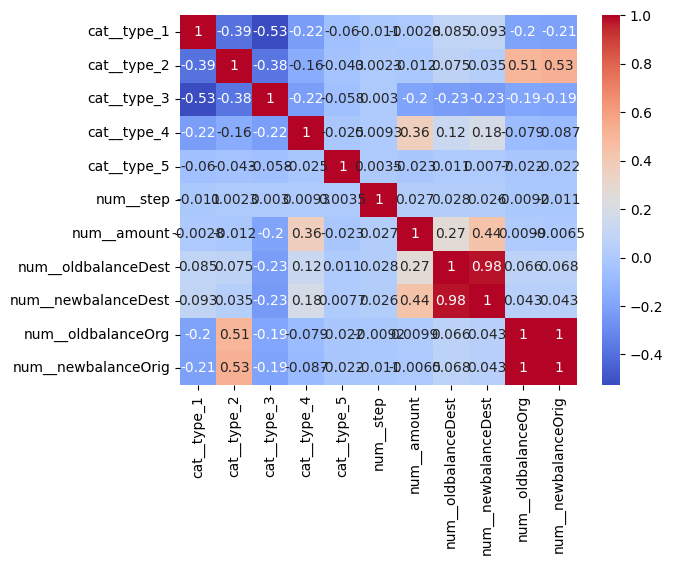

In [ ]:
sns.heatmap(X_train.corr(), cmap = "coolwarm", annot=True)

In [ ]:
sns.pairplot(X_train)

MemoryError: Unable to allocate 12.3 MiB for an array with shape (1606570,) and data type object

Error in callback <function _draw_all_if_interactive at 0x0000029AFB31A2A0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
stop

NameError: name 'stop' is not defined

## preprocessing 2

## iso

In [ ]:
iso = IsolationForest(contamination=.1, n_estimators=300)
iso.fit(X_train)
pred = (iso.predict(X_test) == -1).astype(int)
pred_train = (iso.predict(X_train) == -1).astype(int)
print("train\n", classification_report(y_train, pred_train))
print("test\n", classification_report(y_test, pred))

train
               precision    recall  f1-score   support

           0       1.00      0.90      0.95   1600027
           1       0.02      0.53      0.04      6543

    accuracy                           0.90   1606570
   macro avg       0.51      0.72      0.49   1606570
weighted avg       0.99      0.90      0.94   1606570

test
               precision    recall  f1-score   support

           0       1.00      0.90      0.95    399973
           1       0.02      0.54      0.04      1670

    accuracy                           0.90    401643
   macro avg       0.51      0.72      0.50    401643
weighted avg       0.99      0.90      0.94    401643



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
rf_model = RandomForestClassifier(n_estimators=200, 
                                  class_weight='balanced', 
                                  scale_pos_weight = scale_pos_weight,
                                  max_depth=10,
                                  random_state=42, 
                                  n_jobs=-1)

print("🌲 جاري تدريب الـ Random Forest...")
rf_model.fit(X_train, y_train) 

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

TypeError: RandomForestClassifier.__init__() got an unexpected keyword argument 'scale_pos_weight'

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
param_dist = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 400, 600],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',  
    cv=3,
    verbose=2,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print(search.best_score_)
print(search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
0.908811776795968


AttributeError: 'RandomizedSearchCV' object has no attribute 'best_parameters_'

## final model

In [ ]:
search.best_params_

{'subsample': 0.7,
 'n_estimators': 400,
 'max_depth': 8,
 'learning_rate': 0.1,
 'colsample_bytree': 1.0}

In [ ]:
from sklearn.metrics import confusion_matrix

best_model = XGBClassifier(scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', n_estimators = 400, max_depth = 8, colsample_bytree = 1, learning_rate = 0.1, subsample = 0.7)
best_model.fit(X_train, y_train)
pred_train = best_model.predict(X_train)
pres_test = best_model.predict(X_test)

print("test\n")
print(classification_report(y_test, pres_test))
print(confusion_matrix(y_test, pres_test))

print("train\n")
print(classification_report(y_train, pred_train))
print(confusion_matrix(y_train, pred_train))

test

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    399973
           1       0.84      0.97      0.90      1670

    accuracy                           1.00    401643
   macro avg       0.92      0.99      0.95    401643
weighted avg       1.00      1.00      1.00    401643

[[399667    306]
 [    43   1627]]
train

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1600027
           1       0.91      1.00      0.95      6543

    accuracy                           1.00   1606570
   macro avg       0.95      1.00      0.98   1606570
weighted avg       1.00      1.00      1.00   1606570

[[1599361     666]
 [      0    6543]]


In [ ]:
joblib.dump(best_model, "model.pkl")

['model.pkl']